In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce

In [ ]:
data = pd.read_csv('wine_cleared.csv')
data['price_round'] = data['price'].round().astype(int)
regex =r'\d{4}'
data['year'] = data['title'].str.findall(regex).str.get(0)
#data['is_usa'] = data['country'].apply(lambda x: 1 if x == 'US' else 0)
# regex = r'\((.*?)\)'
# data['locality'] = data['title'].str.findall(regex).str.get(0)
# data['locality'].value_counts(normalize=True) * 100

country_population = pd.read_csv('country_population.csv', sep=';')

mask = country_population['country'] == 'Italy'
country_population[mask]

data.join(country_population.set_index('country'), on='country')

country_area = pd.read_csv('country_area.csv', sep=';')

wine_title = 'Gård 2014 Grand Klasse Reserve Lawrence Vineyards Viognier (Columbia Valley (WA))'
data = data.merge(country_area[['country', 'area']], on='country', how='left')
wine_info = data[data['title'] == wine_title]

data['year'] = pd.to_datetime(data['year'], errors = 'coerce')

data['years_diff'] = (pd.to_datetime("2022-01-12") - data['year']).dt.days
data['years_diff'].max()


import pandas as pd
import dtale

df = pd.read_csv('wine.csv')
d = dtale.show(df)Ы

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 119988 entries, 0 to 119987
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   country                119988 non-null  str           
 1   description            119988 non-null  str           
 2   designation            119988 non-null  str           
 3   points                 119988 non-null  int64         
 4   price                  119988 non-null  float64       
 5   province               119988 non-null  str           
 6   region_1               119988 non-null  str           
 7   taster_name            119988 non-null  str           
 8   taster_twitter_handle  119988 non-null  str           
 9   title                  119988 non-null  str           
 10  variety                119988 non-null  str           
 11  winery                 119988 non-null  str           
 12  price_round            119988 non-null  int64         


In [3]:
import pandas as pd
# инициализируем информацию об одежде
clothing_list = [
    ['xxs', 'dress'],
    ['xxs', 'skirt'],
    ['xs', 'dress'],
    ['s', 'skirt'],
    ['m', 'dress'],
    ['l', 'shirt'],
    ['s', 'coat'],
    ['m', 'coat'],
    ['xxl', 'shirt'],
    ['l', 'dress']
]

clothing = pd.DataFrame(clothing_list, columns = ['size',  'type'])
clothing

# импортируем библиотеку для работы с кодировщиками
import category_encoders as ce 

# создаем объект OrdinalEncoder, col - имя столбца, mapping - словарь с описанием кодировки
ord_encoder = ce.OrdinalEncoder(mapping=[{
	'col': 'size',
	'mapping': {'xxs': 1, 'xs': 2, 's': 3, 
                'm': 4, 'l': 5, 'xxl': 6}
}])
# применяем трансформацию к столбцу
data_bin = ord_encoder.fit_transform(clothing[['size']])
# добавляем результат к исходному DataFrame
clothing = pd.concat([clothing, data_bin], axis=1)


import category_encoders as ce # импорт для работы с кодировщиком

encoder = ce.OneHotEncoder(cols=['type'], use_cat_names=True) # указываем столбец для кодирования
type_bin = encoder.fit_transform(clothing['type'])
clothing = pd.concat([clothing, type_bin], axis=1)

clothing


import category_encoders as ce

encoder = ce.OneHotEncoder(cols=['taster_name'])
type_bin = encoder.fit_transform(data['taster_name'])
data = pd.concat([data, type_bin], axis=1)

#data



In [4]:
bin_encoder = ce.BinaryEncoder(cols=['country'])
country_bin = bin_encoder.fit_transform(data['country'])
data = pd.concat([data, country_bin], axis=1)
data.head()

import category_encoders as ce

encoder = ce.BinaryEncoder(cols=['taster_twitter_handle'])
type_bin = encoder.fit_transform(data['taster_twitter_handle'])
data = pd.concat([data, type_bin], axis=1)

import category_encoders as ce
list_of_dicts = [
 {'product': 'Product1', 'price': 1200, 'payment_type': 'Mastercard'},
 {'product': 'Product2', 'price': 3600, 'payment_type': 'Visa'},
 {'product': 'Product3', 'price': 7500, 'payment_type': 'Amex'}
]
df = pd.DataFrame(list_of_dicts)
encoder = ce.OneHotEncoder(cols=['product','payment_type'])
cols = encoder.fit_transform(df[['product','payment_type']])
df = pd.concat([df, cols], axis=1)

data.head()

# Улученная версия кода
import category_encoders as ce

# Binary encoding
encoder_bin = ce.BinaryEncoder(cols=['taster_twitter_handle'])
data = encoder_bin.fit_transform(data)

# One-hot encoding
encoder_ohe = ce.OneHotEncoder(cols=['product', 'payment_type'])
df = encoder_ohe.fit_transform(df)


ValueError: cannot reindex on an axis with duplicate labels

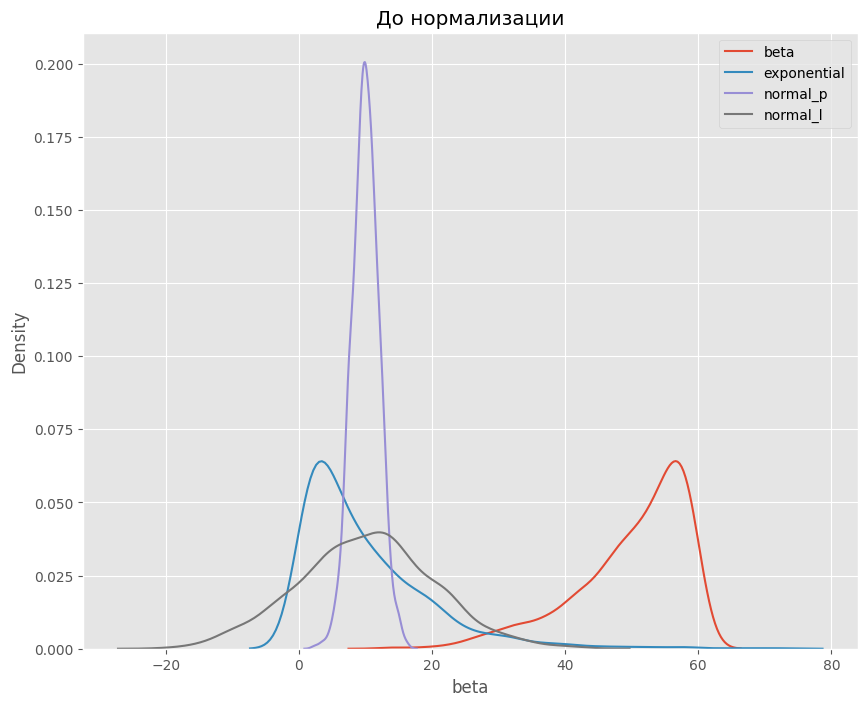

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(34)

# для нормализации, стандартизации
from sklearn import preprocessing

# Для графиков
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
matplotlib.style.use('ggplot')

# сгенерируем датасет из случайных чисел
df = pd.DataFrame({ 
    # Бета распределение, 5 – значение альфа, 1 – значение бета, 1000 – размер
    'beta': np.random.beta(5, 1, 1000) * 60,
    
    # Экспоненциальное распределение, 10 – "резкость" экспоненты, 1000 – размер
    'exponential': np.random.exponential(10, 1000),
    
    # Нормальное распределение, 10 – среднее значение р., 2 – стандартное отклонение, 1000 – количество сэмплов
    'normal_p': np.random.normal(10, 2, 1000),
    
    # Нормальное распределение, 10 – среднее значение р., 10 – стандартное отклонение, 1000 – количество сэмплов
    'normal_l': np.random.normal(10, 10, 1000),
})

# Копируем названия столбцов, которые теряются при использовании fit_transform()
col_names = list(df.columns)

fig, (ax1) = plt.subplots(ncols=1, figsize=(10, 8))
ax1.set_title('До нормализации')
sns.kdeplot(df['beta'], ax=ax1, label='beta')
sns.kdeplot(df['exponential'], ax=ax1, label='exponential')
sns.kdeplot(df['normal_p'], ax=ax1, label='normal_p')
sns.kdeplot(df['normal_l'], ax=ax1, label='normal_l')
plt.legend()
plt.show()

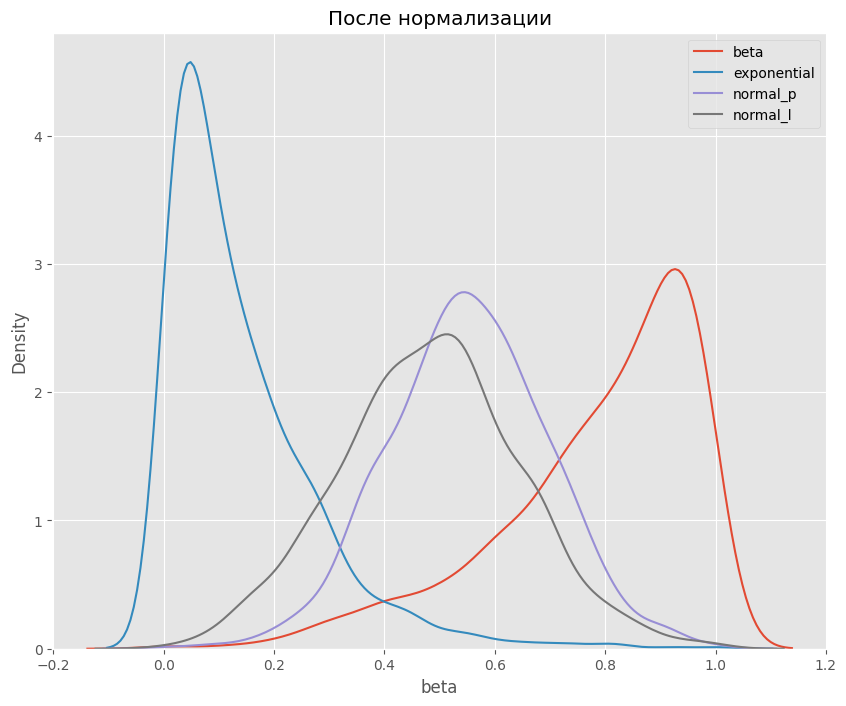

In [ ]:
df.describe()

mm_scaler = preprocessing.MinMaxScaler()
df_mm = mm_scaler.fit_transform(df)
df_mm = pd.DataFrame(df_mm, columns=col_names)
fig, (ax1) = plt.subplots(ncols=1, figsize=(10, 8))
ax1.set_title('После нормализации')
sns.kdeplot(df_mm['beta'], ax=ax1, label='beta')
sns.kdeplot(df_mm['exponential'], ax=ax1, label='exponential')
sns.kdeplot(df_mm['normal_p'], ax=ax1, label='normal_p')
sns.kdeplot(df_mm['normal_l'], ax=ax1, label='normal_l')
plt.legend()
plt.show()

In [ ]:
def encode_binary(self, columns, drop_original=False):
    new_features = []
    
    for col in columns:
        encoder = ce.BinaryEncoder(cols=[col])
        encoded = encoder.fit_transform(self.data[[col]])
        
        self.encoders[f'binary_{col}'] = encoder
        
        encoded.columns = [f"{col}_bit{i}" for i in range(encoded.shape[1])]
        self.encoded_columns[col] = list(encoded.columns)
        
        new_features.append(encoded)
        
        if drop_original:
            self.data = self.data.drop(columns=[col])
    
    self.data = pd.concat([self.data] + new_features, axis=1)
    return self